# Settings

In [1]:
library(stringr)
library(jsonlite)
library(RCurl)
library(dplyr)
library(gplots)
library(RColorBrewer)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess




In [2]:
# Input files
# - rowdata gene table from
rowdata.file <- "../rowdata_mouse.rds"
# - rowdata column to use for matching
match.col <- "gene_id_base"
# - unformatted expression data 
expr.file <- "../../input_data/ENCODE/metadata_encode_default_01172025.tsv"

# Output files
out.files <- list("coldata" = "coldata.rds",
                  "exprmat" = "exprmat.rds",
                  "layout" = "layout.rds")

# Load input data

In [3]:
rowdata <- readRDS(rowdata.file)
nrow(rowdata)
head(rowdata)

[1] 42319

,source,type,gene_id,gene_type,gene_name,level,havana_gene,tag,gene_id_base,chr,⋯,hem_early_adult,sucessful_procedures_13,ortholog,hgnc_id,gene_symbol,mean_depmap_gene_effect_score,depmap_essential_05,depmap_essential_1,fusil_all,fusil
,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
MGI:1918911,HAVANA,gene,ENSMUSG00000109644.4,lncRNA,0610005C13Rik,2,OTTMUSG00000030340.1,NA,ENSMUSG00000109644,chr7,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1923503,HAVANA,gene,ENSMUSG00000108652.3,lncRNA,0610006L08Rik,2,OTTMUSG00000058385.1,overlapping_locus,ENSMUSG00000108652,chr7,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:3698435,HAVANA,gene,ENSMUSG00000086714.4,lncRNA,0610009E02Rik,2,OTTMUSG00000012797.1,overlapping_locus,ENSMUSG00000086714,chr2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1914088,HAVANA,gene,ENSMUSG00000043644.7,lncRNA,0610009L18Rik,2,OTTMUSG00000004146.1,NA,ENSMUSG00000043644,chr11,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
MGI:1915609,HAVANA,gene,ENSMUSG00000020831.19,protein_coding,0610010K14Rik,2,OTTMUSG00000006039.1,overlapping_locus,ENSMUSG00000020831,chr11,⋯,NA,NA,one2one,HGNC:28737,C17orf49,-0.3500019,n,n,DL,DL
MGI:1918926,HAVANA,gene,ENSMUSG00000089755.2,lncRNA,0610012D04Rik,2,OTTMUSG00000028524.1,NA,ENSMUSG00000089755,chr17,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


# Get ENCODE RNA-seq data

In [4]:
# Get sample and other experimental metadata from ENCODE database (long step)

files <- read.delim(expr.file, as.is=T, sep="\t")
files <- files[which(files$Output.type=="gene quantifications" & files$File.assembly=="mm10"),]
link.prefix <- "https://www.encodeproject.org"

categories.to.capture <- c("file.accession", # file.json$accession
                           "experiment.accession", # exp.json$accession
                           "biosample.summary", # exp.json$biosample_summary
                           "biosample.term", # file.json$biosample_ontology$term_name 
                           "biosample.classification", # file.json$biosample_ontology$classification
                           "experiment.description", # exp.json$description
                           "experiment", # file.json$dataset
                           "project", # file.json$award$project
                           "rfa", # file.json$award$rfa
                           "date.submitted", # exp.json$date_submitted
                           "lab", # exp.json$lab 
                           "biological.replicate", # file.json$biological_replicates
                           "technical.replicate", #file.json$technical_replicates
                           "download.url") #file.json$href)
file.table <- data.frame(matrix(NA, nrow=nrow(files), ncol=length(categories.to.capture)))
colnames(file.table) <- categories.to.capture
                        
for(f in seq(nrow(files))){
    temp.link <- paste(link.prefix, "/files/", files$File.accession[f], "?format=JSON", sep="")
    file.json <- fromJSON(temp.link)
    exp.json <- fromJSON(paste(link.prefix, file.json$dataset, "?format=JSON", sep=""))
    file.table$file.accession[f] <- file.json$accession
    file.table$experiment.accession[f] <- exp.json$accession
    file.table$biosample.summary[f] <- exp.json$biosample_summary
    file.table$biosample.term[f] <- file.json$biosample_ontology$term_name
    file.table$biosample.classification[f] <- file.json$biosample_ontology$classification
    file.table$experiment.description[f] <- exp.json$description
    file.table$experiment[f] <- file.json$dataset
    file.table$project[f] <- file.json$award$project
    file.table$rfa[f] <- file.json$award$rfa
    file.table$date.submitted[f] <- exp.json$date_submitted
    file.table$lab[f] <- exp.json$lab$name
    file.table$biological.replicate[f] <- file.json$biological_replicates
    file.table$technical.replicate[f] <- file.json$technical_replicates
    file.table$download.url[f] <- file.json$href}
nrow(file.table)
head(file.table)         

[1] 109

,file.accession,experiment.accession,biosample.summary,biosample.term,biosample.classification,experiment.description,experiment,project,rfa,date.submitted,lab,biological.replicate,technical.replicate,download.url
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,ENCFF410KMF,ENCSR096STK,Mus musculus strain B6NCrl liver tissue postnatal (0 days),liver,tissue,PolyA RNA-Seq from oligo-dT primed Total RNA on mouse liver,/experiments/ENCSR096STK/,ENCODE,ENCODE4,2015-03-27,barbara-wold,1,1_1,/files/ENCFF410KMF/@@download/ENCFF410KMF.tsv
2,ENCFF554PCI,ENCSR727FHP,Mus musculus strain B6NCrl heart tissue embryo (14.5 days),heart,tissue,PolyA RNA-Seq from oligo-dT primed Total RNA on embryonic 14.5 day mouse heart,/experiments/ENCSR727FHP/,ENCODE,ENCODE4,2014-12-12,barbara-wold,2,2_1,/files/ENCFF554PCI/@@download/ENCFF554PCI.tsv
3,ENCFF876OPZ,ENCSR000CHA,Mus musculus strain B6NCrl kidney tissue male adult (2 months),kidney,tissue,RNA-seq on 8 week adult mouse kidney,/experiments/ENCSR000CHA/,ENCODE,ENCODE4,2011-08-04,bing-ren,1,1_1,/files/ENCFF876OPZ/@@download/ENCFF876OPZ.tsv
4,ENCFF322QGD,ENCSR870AQU,Mus musculus strain C57BL/6J lung tissue female adult (10 weeks),lung,tissue,RNA-seq of mouse lung tissue. The second technical replicate was performed in May 2015 and was not part of the original Lin et al. 2014 publication (PMID:25413365).,/experiments/ENCSR870AQU/,ENCODE,ENCODE4,2014-12-08,michael-snyder,1,1_2,/files/ENCFF322QGD/@@download/ENCFF322QGD.tsv
5,ENCFF609VXF,ENCSR516UNF,Mus musculus strain C57BL/6J ovary tissue female adult (10 weeks),ovary,tissue,RNA-seq in mouse ovary.,/experiments/ENCSR516UNF/,ENCODE,ENCODE4,2014-12-03,michael-snyder,1,1_1,/files/ENCFF609VXF/@@download/ENCFF609VXF.tsv
6,ENCFF588EWC,ENCSR000CGT,Mus musculus strain B6NCrl bone marrow tissue male adult (2 months),bone marrow,tissue,RNA-seq on 8 week adult mouse bone marrow,/experiments/ENCSR000CGT/,ENCODE,ENCODE4,2011-08-04,bing-ren,2,2_1,/files/ENCFF588EWC/@@download/ENCFF588EWC.tsv


In [5]:
#extract developmental stage from biosample summary and add as metadata
extract.stage <- function(str, labels=c("days","weeks","months")){
    if(grepl("embryo",str)){
        temp.st <- str_locate(str," days")[1] 
        temp.sub <- str_sub(str, temp.st-5, temp.st-1)
        temp.st.2 <- str_locate(temp.sub,"[0-9]")[1]
        temp.sub.2 <- str_sub(temp.sub, temp.st.2, nchar(temp.sub)) %>% gsub(pattern="\\.", replacement="-")
        temp.sub.2 <- paste0("E", temp.sub.2)
        return(temp.sub.2)}
    index <- which(paste0(labels,")") %in% unlist(strsplit(str, split="\\s")))
    temp.st <- str_locate(str, paste0(" ",labels[index]))[1]
    temp.sub <- str_sub(str, temp.st-5, temp.st-1)
    temp.st.2 <- str_locate(temp.sub,"[0-9]")[1]
    #return(temp.st.2)
    temp.sub.2 <- str_sub(temp.sub, temp.st.2, nchar(temp.sub)) %>% gsub(pattern="\\.", replacement="-")
    temp.sub.2 <- paste0("P", temp.sub.2, labels[index])
    return(temp.sub.2)
}
file.table$stage <- lapply(file.table$biosample.summary, FUN=extract.stage) %>% unlist()
table(file.table$stage)


   E10-5    E11-5    E12-5    E13-5    E14-5    E15-5    E16-5   P0days 
       6        8        8        8       16       12        9       15 
P10weeks P24weeks P2months 
      13        1       13 

In [6]:
#subset stages with consistent sample coverage
stages.sub <- c('E10-5',
                'E11-5',
                'E12-5',
                'E13-5',
                'E14-5',
                'E15-5',
                'E16-5',
                'P0days',
                'P2months',
                'P10weeks')
file.table.filt <- file.table %>% filter(stage %in% stages.sub)
nrow(file.table.filt)
table(file.table.filt$stage)

[1] 108


   E10-5    E11-5    E12-5    E13-5    E14-5    E15-5    E16-5   P0days 
       6        8        8        8       16       12        9       15 
P10weeks P2months 
      13       13 

In [7]:
# subset tissues with consistent coverage across multiple stages
file.table.filt$tissue <- gsub(file.table.filt$biosample.term, pattern=" ", replacement="-")
tissues.sub <- c('forebrain',
                 'midbrain',
                 'hindbrain',
                 'neural-tube',
                 'liver',
                 'heart',
                 'embryonic-facial-prominence',
                 'limb',
                 'intestine',
                 'stomach',
                 'kidney',
                 'lung')
file.table.filt <- file.table.filt %>% filter(tissue %in% tissues.sub)
nrow(file.table.filt)
table(file.table.filt$tissue)
table(file.table.filt$stage)

[1] 84


embryonic-facial-prominence                   forebrain 
                          6                           8 
                      heart                   hindbrain 
                         11                           8 
                  intestine                      kidney 
                          4                           6 
                       limb                       liver 
                          7                          10 
                       lung                    midbrain 
                          6                           8 
                neural-tube                     stomach 
                          6                           4 


   E10-5    E11-5    E12-5    E13-5    E14-5    E15-5    E16-5   P0days 
       6        8        8        8       15       12        9       10 
P10weeks P2months 
       4        4 

In [8]:
#add a label for each sample
file.table.filt$label <- paste(file.table.filt$tissue, file.table.filt$stage, sep="_")
#filter out few redundandant sampels (3 E14.5 tissues profiled by both Wold and Ren labs. Keeping Wold lab toi match the majority of other samples)
temp.dups <- which(duplicated(file.table.filt$label))
file.table.filt <- file.table.filt %>% 
    filter(!duplicated(label))
length(file.table.filt$label)
length(unique(file.table.filt$label))
head(file.table.filt$label)

[1] 81

[1] 81

[1] "liver_P0days"    "heart_E14-5"     "kidney_P2months" "lung_P10weeks"  
[5] "limb_E14-5"      "liver_E11-5"

In [9]:
# iterate through files, download, and extract TPM values (long step)

temp.mat <- data.frame("mgi_id"=rownames(rowdata),
                      "gene_id_base"=rowdata$gene_id_base)
tempfile <- tempfile()

for(f in seq(nrow(file.table.filt))){
    download.file(paste(link.prefix, file.table.filt$download.url[f], sep=""), tempfile)
    temp.expression <- read.table(tempfile, as.is=T, header=T) %>% 
        filter(grepl("ENSMUSG", gene_id))
    rownames(temp.expression) <- temp.expression$gene_id %>%
        lapply(FUN=strsplit, split="\\.") %>%
        unlist() %>%
        matrix(ncol=2, byrow=T)  %>%
        subset.matrix(select = 1) %>%
        as.character()
    temp.mat <- left_join(temp.mat, 
              tibble::rownames_to_column(temp.expression, var="gene_id_base") %>% select(c(gene_id_base, TPM)), 
              by="gene_id_base")
    colnames(temp.mat)[ncol(temp.mat)] <- file.table.filt$label[f]
    file.remove(tempfile)
}
nrow(temp.mat)
head(temp.mat)

[1] 42319

,mgi_id,gene_id_base,liver_P0days,heart_E14-5,kidney_P2months,lung_P10weeks,limb_E14-5,liver_E11-5,midbrain_E11-5,lung_E14-5,⋯,forebrain_E15-5,heart_P0days,hindbrain_E15-5,liver_E13-5,midbrain_E10-5,limb_E12-5,hindbrain_E12-5,intestine_E16-5,neural-tube_E15-5,heart_E16-5
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MGI:1918911,ENSMUSG00000109644,164.14,0.36,138.91,0.00,0,26.41,0.43,0.50,⋯,1.54,1.15,1.29,40.10,0.68,1.95,1.68,69.59,1.82,1.11
2,MGI:1923503,ENSMUSG00000108652,0.02,0.06,26.45,0.00,0,0.00,0.00,0.00,⋯,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.02,0.05,0.00
3,MGI:3698435,ENSMUSG00000086714,1.61,2.28,2.05,1.99,0,1.57,1.93,1.41,⋯,4.94,4.15,4.41,1.03,3.76,3.74,4.34,4.13,5.19,5.08
4,MGI:1914088,ENSMUSG00000043644,4.82,19.04,4.82,7.48,0,2.06,4.57,4.45,⋯,9.50,25.32,7.19,1.67,3.11,6.65,6.93,6.88,7.69,16.53
5,MGI:1915609,ENSMUSG00000020831,41.65,102.84,21.55,62.45,0,101.98,170.03,136.94,⋯,150.26,74.39,134.86,74.36,197.62,176.94,162.53,105.39,130.25,88.07
6,MGI:1918926,ENSMUSG00000089755,0.13,0.00,0.13,0.00,0,0.00,0.00,0.00,⋯,0.00,0.06,0.00,0.06,0.00,0.12,0.00,0.00,0.00,0.00


# Make coldata table

In [10]:
coldata <- file.table.filt
rownames(coldata) <- coldata$label
coldata$label <- NULL
nrow(coldata)
head(coldata)
table(coldata$stage)
table(coldata$tissue)

[1] 81

,file.accession,experiment.accession,biosample.summary,biosample.term,biosample.classification,experiment.description,experiment,project,rfa,date.submitted,lab,biological.replicate,technical.replicate,download.url,stage,tissue
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
liver_P0days,ENCFF410KMF,ENCSR096STK,Mus musculus strain B6NCrl liver tissue postnatal (0 days),liver,tissue,PolyA RNA-Seq from oligo-dT primed Total RNA on mouse liver,/experiments/ENCSR096STK/,ENCODE,ENCODE4,2015-03-27,barbara-wold,1,1_1,/files/ENCFF410KMF/@@download/ENCFF410KMF.tsv,P0days,liver
heart_E14-5,ENCFF554PCI,ENCSR727FHP,Mus musculus strain B6NCrl heart tissue embryo (14.5 days),heart,tissue,PolyA RNA-Seq from oligo-dT primed Total RNA on embryonic 14.5 day mouse heart,/experiments/ENCSR727FHP/,ENCODE,ENCODE4,2014-12-12,barbara-wold,2,2_1,/files/ENCFF554PCI/@@download/ENCFF554PCI.tsv,E14-5,heart
kidney_P2months,ENCFF876OPZ,ENCSR000CHA,Mus musculus strain B6NCrl kidney tissue male adult (2 months),kidney,tissue,RNA-seq on 8 week adult mouse kidney,/experiments/ENCSR000CHA/,ENCODE,ENCODE4,2011-08-04,bing-ren,1,1_1,/files/ENCFF876OPZ/@@download/ENCFF876OPZ.tsv,P2months,kidney
lung_P10weeks,ENCFF322QGD,ENCSR870AQU,Mus musculus strain C57BL/6J lung tissue female adult (10 weeks),lung,tissue,RNA-seq of mouse lung tissue. The second technical replicate was performed in May 2015 and was not part of the original Lin et al. 2014 publication (PMID:25413365).,/experiments/ENCSR870AQU/,ENCODE,ENCODE4,2014-12-08,michael-snyder,1,1_2,/files/ENCFF322QGD/@@download/ENCFF322QGD.tsv,P10weeks,lung
limb_E14-5,ENCFF785MZJ,ENCSR000CHJ,Mus musculus strain B6NCrl limb tissue embryo (14.5 days),limb,tissue,RNA-seq on 14.5 day embryonic mouse limb,/experiments/ENCSR000CHJ/,ENCODE,ENCODE4,2012-01-04,bing-ren,1,1_1,/files/ENCFF785MZJ/@@download/ENCFF785MZJ.tsv,E14-5,limb
liver_E11-5,ENCFF557PQT,ENCSR284AMY,Mus musculus strain B6NCrl liver tissue embryo (11.5 days),liver,tissue,PolyA RNA-Seq from oligo-dT primed Total RNA on 10ng of embryonic 11.5 day (e11.5) mouse liver,/experiments/ENCSR284AMY/,ENCODE,ENCODE4,2014-11-06,barbara-wold,1,1_1,/files/ENCFF557PQT/@@download/ENCFF557PQT.tsv,E11-5,liver



   E10-5    E11-5    E12-5    E13-5    E14-5    E15-5    E16-5   P0days 
       6        8        8        8       12       12        9       10 
P10weeks P2months 
       4        4 


embryonic-facial-prominence                   forebrain 
                          6                           8 
                      heart                   hindbrain 
                         10                           8 
                  intestine                      kidney 
                          4                           6 
                       limb                       liver 
                          6                           9 
                       lung                    midbrain 
                          6                           8 
                neural-tube                     stomach 
                          6                           4 

# Make counts table

In [11]:
# make exprmat
n.offset.columns <- 2
exprmat <- apply(temp.mat[,(n.offset.columns+1):ncol(temp.mat)], 2, as.numeric)
rownames(exprmat) <- temp.mat$mgi_id
colnames(exprmat) <- colnames(temp.mat)[(n.offset.columns+1):ncol(temp.mat)]
nrow(exprmat)
head(exprmat)

[1] 42319

,liver_P0days,heart_E14-5,kidney_P2months,lung_P10weeks,limb_E14-5,liver_E11-5,midbrain_E11-5,lung_E14-5,forebrain_E14-5,forebrain_P0days,⋯,forebrain_E15-5,heart_P0days,hindbrain_E15-5,liver_E13-5,midbrain_E10-5,limb_E12-5,hindbrain_E12-5,intestine_E16-5,neural-tube_E15-5,heart_E16-5
MGI:1918911,164.14,0.36,138.91,0.00,0,26.41,0.43,0.50,0.30,0.95,⋯,1.54,1.15,1.29,40.10,0.68,1.95,1.68,69.59,1.82,1.11
MGI:1923503,0.02,0.06,26.45,0.00,0,0.00,0.00,0.00,0.00,0.29,⋯,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.02,0.05,0.00
MGI:3698435,1.61,2.28,2.05,1.99,0,1.57,1.93,1.41,3.22,4.36,⋯,4.94,4.15,4.41,1.03,3.76,3.74,4.34,4.13,5.19,5.08
MGI:1914088,4.82,19.04,4.82,7.48,0,2.06,4.57,4.45,7.88,10.75,⋯,9.50,25.32,7.19,1.67,3.11,6.65,6.93,6.88,7.69,16.53
MGI:1915609,41.65,102.84,21.55,62.45,0,101.98,170.03,136.94,192.67,132.84,⋯,150.26,74.39,134.86,74.36,197.62,176.94,162.53,105.39,130.25,88.07
MGI:1918926,0.13,0.00,0.13,0.00,0,0.00,0.00,0.00,0.00,0.00,⋯,0.00,0.06,0.00,0.06,0.00,0.12,0.00,0.00,0.00,0.00


# Format layout

In [12]:
# order stages for display (no change in this case)
length(stages.sub)
stages.sub
stages.sub.ord <- stages.sub
length(stages.sub.ord)
stages.sub.ord

[1] 10

[1] "E10-5"    "E11-5"    "E12-5"    "E13-5"    "E14-5"    "E15-5"   
 [7] "E16-5"    "P0days"   "P2months" "P10weeks"

[1] 10

[1] "E10-5"    "E11-5"    "E12-5"    "E13-5"    "E14-5"    "E15-5"   
 [7] "E16-5"    "P0days"   "P2months" "P10weeks"

In [13]:
# order tissuesfor display (no change in this case)
length(tissues.sub)
tissues.sub
tissues.sub.ord <- tissues.sub
length(tissues.sub.ord)
tissues.sub.ord

[1] 12

[1] "forebrain"                   "midbrain"                   
 [3] "hindbrain"                   "neural-tube"                
 [5] "liver"                       "heart"                      
 [7] "embryonic-facial-prominence" "limb"                       
 [9] "intestine"                   "stomach"                    
[11] "kidney"                      "lung"

[1] 12

[1] "forebrain"                   "midbrain"                   
 [3] "hindbrain"                   "neural-tube"                
 [5] "liver"                       "heart"                      
 [7] "embryonic-facial-prominence" "limb"                       
 [9] "intestine"                   "stomach"                    
[11] "kidney"                      "lung"

Warning message in heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col = my.cols, :
“Discrepancy: Rowv is FALSE, while dendrogram is `both'. Omitting row dendogram.”
Warning message in heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col = my.cols, :
“Discrepancy: Colv is FALSE, while dendrogram is `column'. Omitting column dendogram.”


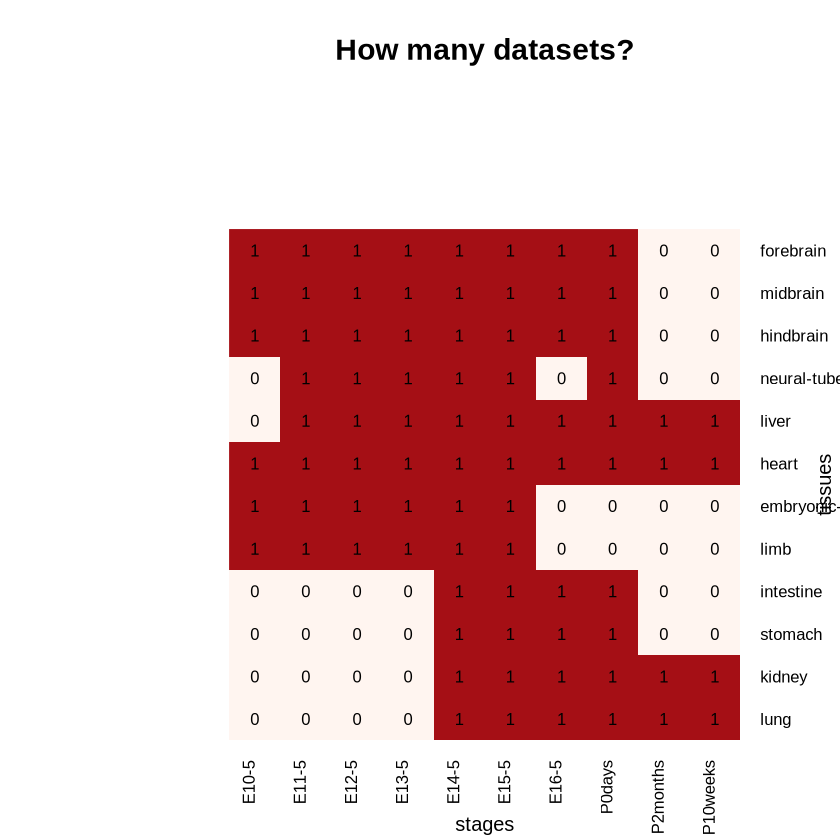

In [14]:
# plot layout as heatmap
my.cex=1
bias=1
my.pal <- c(brewer.pal(9, "Reds")[c(1,4,8)])
my.cols <- colorRampPalette(my.pal, bias=bias)(100)
layout.heatmap <- matrix(NA, nrow=length(tissues.sub.ord), ncol=length(stages.sub.ord))
for(row in seq(length(tissues.sub.ord))){
    for(col in seq(length(stages.sub.ord))){
        layout.heatmap[row, col] <- length(which(coldata$tissue==tissues.sub.ord[row] & 
                                                 coldata$stage==stages.sub.ord[col]))
    }
}
heatmap.2(layout.heatmap, Colv = NA, Rowv = NA, col=my.cols, symbreaks=F,
          tracecol=NA, cexRow=my.cex, cexCol=my.cex, 
          xlab="stages", ylab="tissues", main="How many datasets?",
          labRow=tissues.sub, labCol=stages.sub, key=F, cellnote=round(layout.heatmap, digits=1), notecex=my.cex, notecol="black")

In [15]:
# create layout matrix by sample name
layout <- matrix(NA, nrow=length(tissues.sub.ord), ncol=length(stages.sub.ord))
rownames(layout) <- tissues.sub.ord
colnames(layout) <- stages.sub.ord
for(row in seq(length(tissues.sub.ord))){
    for(col in seq(length(stages.sub.ord))){
        temp.match <- which(coldata$tissue==tissues.sub.ord[row] & 
                            coldata$stage==stages.sub.ord[col])
         if(length(temp.match) == 1){
              layout[row, col] <- rownames(coldata)[temp.match]}
    }
}
layout

,E10-5,E11-5,E12-5,E13-5,E14-5,E15-5,E16-5,P0days,P2months,P10weeks
forebrain,forebrain_E10-5,forebrain_E11-5,forebrain_E12-5,forebrain_E13-5,forebrain_E14-5,forebrain_E15-5,forebrain_E16-5,forebrain_P0days,NA,NA
midbrain,midbrain_E10-5,midbrain_E11-5,midbrain_E12-5,midbrain_E13-5,midbrain_E14-5,midbrain_E15-5,midbrain_E16-5,midbrain_P0days,NA,NA
hindbrain,hindbrain_E10-5,hindbrain_E11-5,hindbrain_E12-5,hindbrain_E13-5,hindbrain_E14-5,hindbrain_E15-5,hindbrain_E16-5,hindbrain_P0days,NA,NA
neural-tube,NA,neural-tube_E11-5,neural-tube_E12-5,neural-tube_E13-5,neural-tube_E14-5,neural-tube_E15-5,NA,neural-tube_P0days,NA,NA
liver,NA,liver_E11-5,liver_E12-5,liver_E13-5,liver_E14-5,liver_E15-5,liver_E16-5,liver_P0days,liver_P2months,liver_P10weeks
heart,heart_E10-5,heart_E11-5,heart_E12-5,heart_E13-5,heart_E14-5,heart_E15-5,heart_E16-5,heart_P0days,heart_P2months,heart_P10weeks
embryonic-facial-prominence,embryonic-facial-prominence_E10-5,embryonic-facial-prominence_E11-5,embryonic-facial-prominence_E12-5,embryonic-facial-prominence_E13-5,embryonic-facial-prominence_E14-5,embryonic-facial-prominence_E15-5,NA,NA,NA,NA
limb,limb_E10-5,limb_E11-5,limb_E12-5,limb_E13-5,limb_E14-5,limb_E15-5,NA,NA,NA,NA
intestine,NA,NA,NA,NA,intestine_E14-5,intestine_E15-5,intestine_E16-5,intestine_P0days,NA,NA
stomach,NA,NA,NA,NA,stomach_E14-5,stomach_E15-5,stomach_E16-5,stomach_P0days,NA,NA


# write output

In [16]:
saveRDS(coldata, file=out.files[["coldata"]])
saveRDS(exprmat, file=out.files[["exprmat"]])
saveRDS(layout, file=out.files[["layout"]])